# Example 15: Mars PNT &mdash; a Walker navigation constellation around Mars

LuPNT is designed for *lunar* Position, Navigation and Timing, but nothing in its core is
Moon-specific: the body models, spherical-harmonic gravity, coordinate frames, numerical dynamics,
plotting, and time systems all generalize to any central body. This tutorial demonstrates that by
building a small **Mars navigation constellation** end to end &mdash; using LuPNT's **native**
`NBodyDynamics` propagator and Mars reference frames throughout &mdash; and evaluating how well it would
let a surface user fix their position.

We will

1. build a Mars force model from LuPNT's **higher-order gravity field** (`Body.Mars`, degree/order
   $8\times8$ from the shipped `Mars50c.cof`),
2. use LuPNT's native Mars frames &mdash; `MARS_CI` (inertial) and `MARS_FIXED` (body-fixed) &mdash; for
   propagation and ground tracks,
3. lay out a **9-satellite, 3-plane Walker constellation** and propagate it with `NBodyDynamics`,
4. visualize the **3-D orbits** and the repeating **ground tracks** with LuPNT's Plotly routines,
5. map the **median PDOP** over the whole surface across several orbits, and
6. run a **user-positioning simulation** &mdash; pseudorange least squares &mdash; at Jezero Crater.

The workflow is identical to the lunar examples; only the central body changes. Every piece of physics
&mdash; gravity, frame rotation, integration &mdash; runs inside LuPNT.


## 0. Imports and Mars body data

LuPNT's `Body.Mars` gives Mars' gravitational parameter and mean radius, and (as of the planet-frame
support) `pnt.plot.plot_body` and `pnt.convert_frame` understand Mars directly. We also grab Mars'
shipped surface texture for the 2-D maps later on.


In [1]:
import os, sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from PIL import Image

# Use THIS repo's pylupnt/data (mirrors the other tutorials).
for _b in [Path.cwd(), *Path.cwd().parents]:
    if (_b / "python/pylupnt/__init__.py").exists():
        sys.path.insert(0, str((_b / "python").resolve()))
        if (_b / "data/LuPNT_data/ephemeris").is_dir():
            os.environ["LUPNT_DATA_PATH"] = str((_b / "data/LuPNT_data").resolve())
        break
import pylupnt as pnt

np.set_printoptions(precision=4, suppress=True)
RAD, DEG = pnt.RAD, pnt.DEG
LUPNT_DATA = os.environ["LUPNT_DATA_PATH"]

# --- Mars constants from LuPNT's body model ---------------------------------
mars_pm = pnt.Body.Mars()              # point-mass body, for GM / R
GM_MARS = float(mars_pm.GM)            # [m^3/s^2]
R_MARS = float(mars_pm.R)              # [m]  mean volumetric radius (3396 km)

# Mars' sidereal rotation period, from the IAU prime-meridian rate LuPNT uses.
W_DOT_MARS = 350.89198226              # [deg/day]
SIDEREAL_DAY = 360.0 / W_DOT_MARS * pnt.SECS_DAY   # [s]

# Surface texture (shipped with LuPNT) for the 2-D ground-track / DOP maps.
MARS_MAP = np.asarray(Image.open(os.path.join(LUPNT_DATA, "topo", "mars_surface.jpg")))

print(f"GM_MARS       = {GM_MARS:.6e} m^3/s^2")
print(f"R_MARS        = {R_MARS/1e3:.1f} km")
print(f"Sidereal day  = {SIDEREAL_DAY/3600:.4f} h   (Mars: 24.6229 h)")
print(f"Mars frames   : {mars_pm.inertial_frame}  /  {mars_pm.fixed_frame}")

# Host heavy interactive figures on lupnt-doc-assets instead of embedding them.
import sys as _sys
from pathlib import Path as _Path
for _p in [_Path.cwd(), *_Path.cwd().parents]:
    if (_p / "python" / "examples" / "_doc_assets.py").exists():
        _sys.path.insert(0, str(_p / "python" / "examples")); break
from _doc_assets import embed_plotly, embed_cesium_scene

[00.01][PyLuPNT] Initializing


GM_MARS       = 4.282838e+13 m^3/s^2
R_MARS        = 3396.0 km
Sidereal day  = 24.6230 h   (Mars: 24.6229 h)
Mars frames   : Frame.MARS_CI  /  Frame.MARS_FIXED


## 1. Mars' higher-order gravity field

A navigation constellation lives or dies by how well we know where the satellites are, which is
governed by the gravity field. Mars is noticeably less spherical than Earth &mdash; its oblateness
$J_2\approx1.96\times10^{-3}$ is about **twice** Earth's &mdash; so a point-mass model would let the
orbits (and the broadcast ephemeris) drift.

`Body.Mars(n, m, gravity_file)` loads the **Mars-50c** spherical-harmonic field that LuPNT ships
(`data/LuPNT_data/gravity/mars/Mars50c.cof`, degree/order 50) and keeps it to the degree/order we ask
for. We use $8\times8$, which captures the dominant oblateness and the largest longitude-dependent
(tesseral) terms while staying fast. We then build an `NBodyDynamics` force model around it &mdash; the
same class the lunar tutorials use, just with a Mars body.


In [2]:
N_GRAV = 8   # spherical-harmonic degree/order of the Mars field

mars = pnt.Body.Mars(N_GRAV, N_GRAV, gravity_file="Mars50c.cof")

dyn = pnt.NBodyDynamics()
dyn.set_frame(mars.inertial_frame)     # MARS_CI (Mars-centered inertial, ICRF-aligned)
dyn.set_units(pnt.SI_UNITS)
dyn.add_body(mars)                     # Mars 8x8 gravity field
dyn.set_integrator(pnt.IntegratorType.RKF45)
params = pnt.IntegratorParams()
params.reltol = 1e-11
params.abstol = 1e-3                   # [m]
dyn.set_integrator_params(params)

# Satellites orbit at ~15,000 km; the Sun's third-body pull and solar radiation pressure there are
# 4-5 orders of magnitude below J2, so the Mars field alone sets the geometry over a few sols.
print("Force model:", [b.name for b in dyn.get_bodies()], f"(gravity {N_GRAV}x{N_GRAV})")

Force model: ['MARS'] (gravity 8x8)


### How big are the higher-order terms?

`NBodyDynamics.compute_accelerations(..., decompose_gravity=True)` splits the total acceleration into
the point-mass term plus each individual spherical-harmonic contribution (`MARS_J2`, `MARS_C22`, ...).
Evaluated on a representative satellite, this is the acceleration budget the constellation actually
experiences: $J_2$ sits four orders of magnitude below the central term but acts *secularly* &mdash; it
steadily rotates each orbit plane &mdash; so it dominates the long-term geometry, while the tesseral and
higher zonal terms add the smaller longitude-dependent structure a repeating ground track feels.


Acceleration budget on a satellite at R_Mars + 15,000 km:
  MARS_gravity     |a| = 1.266e-01 m/s^2
  MARS_J2          |a| = 1.132e-05 m/s^2
  MARS_C22         |a| = 1.485e-06 m/s^2
  MARS_C33         |a| = 1.932e-07 m/s^2
  MARS_C31         |a| = 9.849e-08 m/s^2
  MARS_C32         |a| = 6.208e-08 m/s^2
  MARS_J3          |a| = 4.490e-08 m/s^2
  MARS_C44         |a| = 1.445e-08 m/s^2


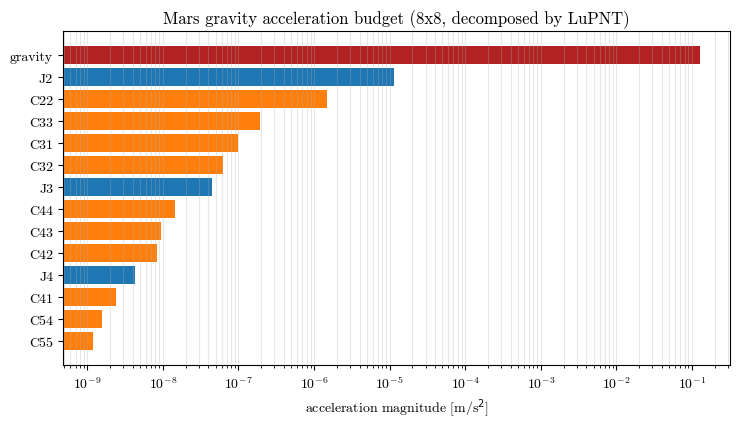

In [3]:
# a representative satellite state at the design altitude (in MARS_CI)
r_demo = np.array([R_MARS + 15000e3, 0.0, 0.0, 0.0, 2400.0, 2400.0])
t_demo = pnt.gregorian_to_time(2035, 1, 1, 0, 0, 0)

acc = dyn.compute_accelerations(t_demo, r_demo, decompose_gravity=True)
mags = {name: float(np.linalg.norm(vec)) for name, vec in acc.items()}
ranked = sorted(mags, key=mags.get, reverse=True)

print("Acceleration budget on a satellite at R_Mars + 15,000 km:")
for name in ranked[:8]:
    print(f"  {name:16s} |a| = {mags[name]:.3e} m/s^2")

# horizontal bar chart of the strongest terms (log scale)
show = [n for n in ranked if mags[n] > 0][:14]
labels = [n.replace("MARS_", "") for n in show]
fig, ax = plt.subplots(figsize=(7.5, 4.4))
colors = ["#b22222" if n == "MARS_gravity" else ("#1f77b4" if n.startswith("MARS_J")
          else "#ff7f0e") for n in show]
ax.barh(range(len(show)), [mags[n] for n in show], color=colors)
ax.set_yticks(range(len(show))); ax.set_yticklabels(labels)
ax.invert_yaxis(); ax.set_xscale("log")
ax.set_xlabel(r"acceleration magnitude [m/s$^2$]")
ax.set_title("Mars gravity acceleration budget (8x8, decomposed by LuPNT)")
ax.grid(True, axis="x", which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Mars reference frames

LuPNT defines, for Mars, a **Mars-centered inertial frame** `MARS_CI` (ICRF-aligned axes) and a
**body-fixed frame** `MARS_FIXED` that co-rotates with the surface, using the IAU orientation model.
`convert_frame` moves states and directions between them &mdash; exactly as it does for `MOON_CI` /
`MOON_PA`.

We can read the rotation rate straight out of the frame conversion: sampling the `MARS_CI`&rarr;`MARS_FIXED`
rotation at two epochs and measuring the angle swept about the pole recovers the Martian sidereal day.


In [4]:
CI, FIXED = mars.inertial_frame, mars.fixed_frame


def rot_ci_to_fixed(t):
    """MARS_CI -> MARS_FIXED rotation matrix, assembled from LuPNT's convert_frame."""
    cols = [np.asarray(pnt.convert_frame(t, e, CI, FIXED, True)) for e in np.eye(3)]
    return np.column_stack(cols)


t0 = pnt.gregorian_to_time(2035, 1, 1, 0, 0, 0)
R0 = rot_ci_to_fixed(t0)
R1 = rot_ci_to_fixed(t0 + 3600.0)
dR = R1 @ R0.T                                   # incremental spin over 1 h
angle = np.arccos(np.clip((np.trace(dR) - 1.0) / 2.0, -1, 1))
period = 2 * np.pi / (angle / 3600.0)
print(f"R orthonormal err : {np.abs(R0 @ R0.T - np.eye(3)).max():.2e}")
print(f"measured Mars day : {period/3600:.4f} h   (sidereal, 24.6229 h)")

R orthonormal err : 2.22e-16
measured Mars day : 24.6230 h   (sidereal, 24.6229 h)


### A Mars-equatorial frame for constellation design

`MARS_CI` is **ICRF-aligned** (its $z$-axis is the ICRF pole, not Mars' pole &mdash; the same convention
as `MOON_CI`). Mars' spin pole is tilted about $37^\circ$ from the ICRF pole, so if we built orbital
elements directly in `MARS_CI`, an "inclination" would be measured against the *wrong* equator.

To design the constellation against **Mars'** equator, we build a Mars-equatorial inertial frame from
LuPNT's own Mars orientation: the body-fixed $z$-axis *is* Mars' pole, so rotating it into `MARS_CI`
gives the pole direction, from which we complete an orthonormal triad. The resulting rotation
`R_eq2ci` maps a state designed in Mars-equatorial coordinates into `MARS_CI` for propagation.


In [5]:
def mars_equatorial_to_ci(t):
    """Rotation from a Mars-equatorial inertial frame (z = Mars pole) to MARS_CI."""
    pole = np.asarray(pnt.convert_frame(t, np.array([0.0, 0.0, 1.0]), FIXED, CI, True))
    pole /= np.linalg.norm(pole)
    x = np.cross([0.0, 0.0, 1.0], pole)          # node of Mars equator on the ICRF equator
    x /= np.linalg.norm(x)
    y = np.cross(pole, x)
    return np.column_stack([x, y, pole])         # columns = equatorial axes in MARS_CI


R_EQ2CI = mars_equatorial_to_ci(t0)
tilt = np.degrees(np.arccos(R_EQ2CI[2, 2]))
print(f"Mars pole tilt from ICRF pole: {tilt:.2f} deg")

Mars pole tilt from ICRF pole: 37.13 deg


## 3. A 9-satellite Walker constellation

We use a **Walker&nbsp;$\delta$** pattern $T/P/F$: $T=9$ satellites in $P=3$ planes (RAAN steps of
$120^\circ$), $F=1$ setting the inter-plane phase, all sharing a circular orbit at $45^\circ$
inclination (w.r.t. Mars' equator). We size the orbit at **15,000&nbsp;km altitude** &mdash; high enough
that each satellite sees a wide cap of the surface (nine satellites is a *minimal* fleet), with a
$\sim21$&nbsp;h period that is deliberately **not** synchronous with the 24.6&nbsp;h Martian day, so the
ground tracks slowly walk westward and every longitude is sampled over a few sols.

Each satellite's classical elements are turned into a Cartesian state with LuPNT's `classical_to_cart`
(in the Mars-equatorial frame) and then rotated into `MARS_CI` for propagation.


In [6]:
N_SAT, N_PLANES, F_WALKER = 9, 3, 1
SATS_PER_PLANE = N_SAT // N_PLANES
ALT = 15000e3
A_SMA = R_MARS + ALT
INC = 45.0 * RAD
PERIOD = 2 * np.pi * np.sqrt(A_SMA ** 3 / GM_MARS)
EPOCH = t0


def walker_elements(T, P, Fp, a, e, inc):
    """Classical elements [a,e,i,RAAN,argp,M] for a Walker-delta constellation."""
    spp = T // P
    coes = []
    for p in range(P):
        raan = p * 2 * np.pi / P
        for s in range(spp):
            M = (s * 2 * np.pi / spp + p * 2 * np.pi * Fp / T) % (2 * np.pi)
            coes.append([a, e, inc, raan, 0.0, M])
    return np.array(coes)


COES = walker_elements(N_SAT, N_PLANES, F_WALKER, A_SMA, 0.0, INC)

# element -> Cartesian (Mars-equatorial) -> MARS_CI
RV0 = np.zeros((N_SAT, 6))
for k, coe in enumerate(COES):
    rv_eq = pnt.classical_to_cart(coe, GM_MARS)
    RV0[k, :3] = R_EQ2CI @ rv_eq[:3]
    RV0[k, 3:] = R_EQ2CI @ rv_eq[3:]

print(f"Walker {N_SAT}/{N_PLANES}/{F_WALKER} constellation")
print(f"  {N_PLANES} planes x {SATS_PER_PLANE} sats,  inclination {INC*DEG:.0f} deg (Mars equator)")
print(f"  altitude {ALT/1e3:.0f} km  (a = {A_SMA/1e3:.0f} km)")
print(f"  orbital period {PERIOD/3600:.2f} h  vs Martian day {SIDEREAL_DAY/3600:.2f} h")

Walker 9/3/1 constellation
  3 planes x 3 sats,  inclination 45 deg (Mars equator)
  altitude 15000 km  (a = 18396 km)
  orbital period 21.04 h  vs Martian day 24.62 h


### Propagate over several orbits with `NBodyDynamics`

We propagate all nine satellites for **two Martian sols** (a little over two orbital periods) at
3-minute sampling, entirely with LuPNT's `NBodyDynamics.propagate` under the $8\times8$ Mars field.
Rotating the inertial states into `MARS_FIXED` with `convert_frame` gives the body-fixed positions
used for ground tracks and user geometry.


In [7]:
T_SIM = 2 * SIDEREAL_DAY
DT = 180.0
TS = EPOCH + np.arange(0.0, T_SIM, DT)
N_T = len(TS)

POS_CI = np.zeros((N_SAT, N_T, 3))
for k in range(N_SAT):
    POS_CI[k] = np.asarray(dyn.propagate(RV0[k], TS))[:, :3]

# inertial -> body-fixed (pure rotation about the shared Mars center)
POS_FIXED = np.zeros((N_SAT, N_T, 3))
for k in range(N_SAT):
    POS_FIXED[k] = np.asarray(pnt.convert_frame(TS, POS_CI[k], CI, FIXED, True))

r_norm = np.linalg.norm(POS_CI, axis=2)
print(f"Propagated {N_SAT} satellites over {T_SIM/SIDEREAL_DAY:.1f} sols "
      f"({N_T} epochs, {T_SIM/PERIOD:.1f} orbital periods)")
print(f"orbit-radius spread [km]: {(r_norm.max()-r_norm.min())/1e3:.1f}  (short-period J2 breathing)")

Propagated 9 satellites over 2.0 sols (985 epochs, 2.3 orbital periods)
orbit-radius spread [km]: 6.9  (short-period J2 breathing)


## 4. The constellation in 3-D

LuPNT's Plotly helpers render the scene: `plot_body` draws the textured Mars globe (Mars is a
first-class body in the plot module now) and `plot_orbits` draws the trajectories &mdash; the same
routines the lunar tutorials use.


In [8]:
n_one = int(np.ceil(PERIOD / DT))          # ~one orbital period, so the plot is not overcrowded
colors = ["#e6194B", "#3cb44b", "#4363d8"]  # one colour per plane

fig = go.Figure()
pnt.plot.plot_body(fig, pnt.MARS, size_factor=6)
for k in range(N_SAT):
    pnt.plot.plot_orbits(fig, POS_CI[k, :n_one], color=colors[k // SATS_PER_PLANE])
fig.add_scatter3d(
    x=POS_CI[:, 0, 0] / 1e6, y=POS_CI[:, 0, 1] / 1e6, z=POS_CI[:, 0, 2] / 1e6,
    mode="markers", marker=dict(size=4, color="black"), name="satellites",
)
pnt.plot.set_view(fig, azimuth=40, elevation=22, zoom=2.6)
fig.update_layout(width=620, height=620,
                  title=f"Mars Walker {N_SAT}/{N_PLANES}/{F_WALKER} constellation (MARS_CI, one period)")
embed_plotly(fig, "ex15_marspnt")

[doc-asset] plots/ex15_marspnt.html  (5648 kB)  ->  https://stanford-navlab.github.io/lupnt-doc-assets/plots/ex15_marspnt.html


## 5. Ground tracks

Reading planetocentric latitude/longitude off the body-fixed positions (LuPNT's
`cart_to_lat_lon_alt`, which returns **degrees**) gives the ground tracks. Because the orbital period
is close to &mdash; but not equal to &mdash; the Martian day, each track is a slowly drifting sinusoid
reaching $\pm45^\circ$ latitude, the three planes offset by $120^\circ$ in longitude.


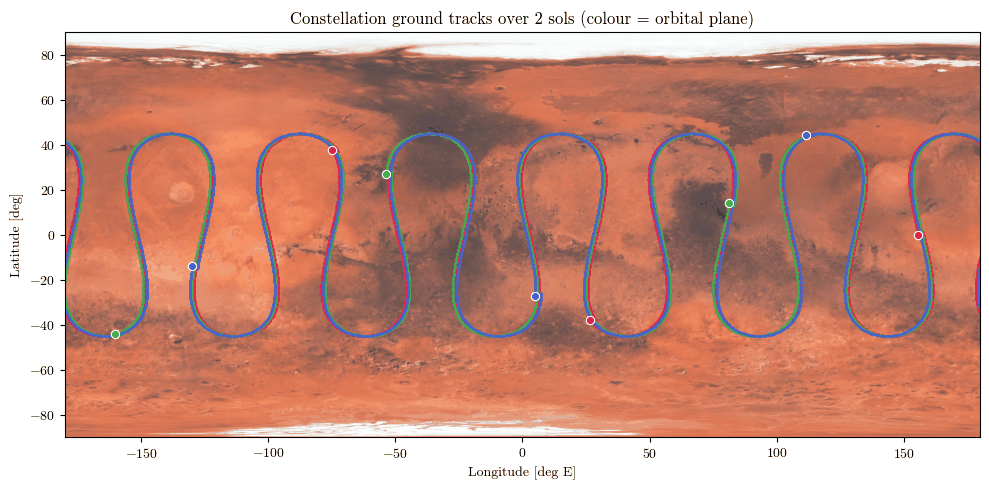

In [9]:
lla = np.array([np.asarray(pnt.cart_to_lat_lon_alt(POS_FIXED[k], R_MARS)) for k in range(N_SAT)])

fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(MARS_MAP, extent=[-180, 180, -90, 90], aspect="auto", origin="upper", alpha=0.85)
for k in range(N_SAT):
    lon = ((lla[k, :, 1] + 180.0) % 360.0) - 180.0
    ax.scatter(lon, lla[k, :, 0], s=1.5, color=colors[k // SATS_PER_PLANE], alpha=0.5)
for k in range(N_SAT):
    lon0 = ((lla[k, 0, 1] + 180.0) % 360.0) - 180.0
    ax.plot(lon0, lla[k, 0, 0], "o", ms=6, color=colors[k // SATS_PER_PLANE], mec="white", mew=0.8)
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
ax.set_xlabel("Longitude [deg E]"); ax.set_ylabel("Latitude [deg]")
ax.set_title("Constellation ground tracks over 2 sols (colour = orbital plane)")
plt.tight_layout()
plt.show()

## 6. Coverage and DOP across the surface

For a surface user, positioning accuracy is range-measurement noise multiplied by the **dilution of
precision**. With line-of-sight unit vectors $\hat{\mathbf u}_i$ (in the user's local East-North-Up
frame) to the visible satellites, the geometry matrix stacks rows $[\hat u_E,\hat u_N,\hat u_U,1]$
(the last column solving for the receiver clock), and

$$Q=(H^{\top}H)^{-1},\qquad \text{PDOP}=\sqrt{Q_{11}+Q_{22}+Q_{33}}.$$

A fix needs at least four satellites above the elevation mask. We sweep a $5^\circ\times5^\circ$
grid, compute PDOP at every epoch, and map the **median PDOP over the two-sol window** &mdash; the
typical geometry a user at each location would experience.


In [10]:
MASK_DEG = 5.0
MASK = np.deg2rad(MASK_DEG)


def pdop_stack(u_enu, visible):
    """Vectorized PDOP over (..., n_sat, 3) LOS unit vectors + boolean visibility."""
    H = np.concatenate([u_enu, np.ones(u_enu.shape[:-1] + (1,))], axis=-1)
    Hw = H * visible[..., None]
    M = np.einsum("...sa,...sb->...ab", Hw, H)
    bad = visible.sum(axis=-1) < 4
    M[bad] = np.eye(4)
    Minv = np.linalg.inv(M)
    pdop = np.sqrt(np.clip(Minv[..., 0, 0] + Minv[..., 1, 1] + Minv[..., 2, 2], 0.0, None))
    pdop[bad] = np.nan
    return pdop


LAT_G = np.arange(-85.0, 85.1, 5.0)
LON_G = np.arange(-180.0, 180.0, 5.0)
med_pdop = np.full((len(LAT_G), len(LON_G)), np.nan)
mean_vis = np.zeros_like(med_pdop)

for i, la in enumerate(LAT_G):                      # loop latitudes (keeps memory small)
    lo = np.deg2rad(LON_G); lar = np.deg2rad(la)
    E = np.stack([-np.sin(lo), np.cos(lo), np.zeros_like(lo)], -1)
    Nn = np.stack([-np.sin(lar) * np.cos(lo), -np.sin(lar) * np.sin(lo),
                   np.full_like(lo, np.cos(lar))], -1)
    Up = np.stack([np.cos(lar) * np.cos(lo), np.cos(lar) * np.sin(lo),
                   np.full_like(lo, np.sin(lar))], -1)
    ru = R_MARS * Up
    los = POS_FIXED[None, :, :, :] - ru[:, None, None, :]        # (nlon,nsat,nT,3)
    e = np.einsum("lc,lstc->lst", E, los)
    n = np.einsum("lc,lstc->lst", Nn, los)
    u = np.einsum("lc,lstc->lst", Up, los)
    rng = np.sqrt(e ** 2 + n ** 2 + u ** 2)
    vis = np.arcsin(np.clip(u / rng, -1, 1)) >= MASK
    u_enu = np.moveaxis(np.stack([e / rng, n / rng, u / rng], -1), 1, 2)  # (nlon,nT,nsat,3)
    vis_t = np.moveaxis(vis, 1, 2)
    med_pdop[i] = np.nanmedian(pdop_stack(u_enu, vis_t), axis=1)
    mean_vis[i] = vis.sum(1).mean(1)

print(f"Global median PDOP  : {np.nanmedian(med_pdop):.2f}")
print(f"Grid fraction with median PDOP < 6 : {np.mean(med_pdop[~np.isnan(med_pdop)] < 6)*100:.0f}%")
print(f"Mean satellites in view (grid avg) : {mean_vis.mean():.2f}")

Global median PDOP  : 6.74
Grid fraction with median PDOP < 6 : 37%
Mean satellites in view (grid avg) : 3.27


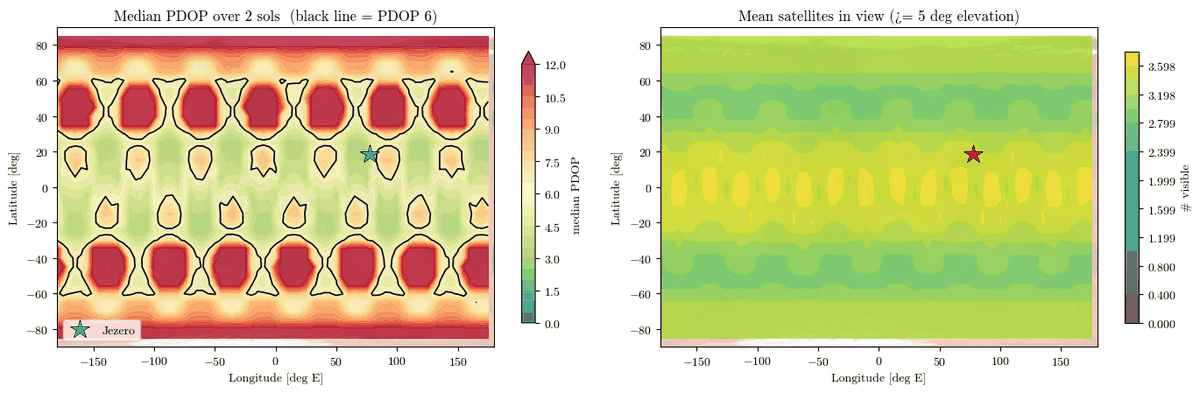

In [11]:
JEZERO = (18.44, 77.45)          # Perseverance rover site (lat N, lon E)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

ax = axes[0]
ax.imshow(MARS_MAP, extent=[-180, 180, -90, 90], aspect="auto", origin="upper", alpha=0.35)
pdop_clip = np.clip(med_pdop, 0, 12)
cf = ax.contourf(LON_G, LAT_G, pdop_clip, levels=np.linspace(0, 12, 25),
                 cmap="RdYlGn_r", alpha=0.75, extend="max")
ax.contour(LON_G, LAT_G, pdop_clip, levels=[6], colors="k", linewidths=1.2)
ax.plot(JEZERO[1], JEZERO[0], "*", ms=16, color="cyan", mec="k", mew=0.6, label="Jezero")
ax.set_title("Median PDOP over 2 sols  (black line = PDOP 6)")
ax.set_xlabel("Longitude [deg E]"); ax.set_ylabel("Latitude [deg]"); ax.legend(loc="lower left")
plt.colorbar(cf, ax=ax, label="median PDOP", shrink=0.85)

ax = axes[1]
ax.imshow(MARS_MAP, extent=[-180, 180, -90, 90], aspect="auto", origin="upper", alpha=0.35)
cf2 = ax.contourf(LON_G, LAT_G, mean_vis, levels=np.linspace(0, mean_vis.max(), 20),
                  cmap="viridis", alpha=0.8)
ax.plot(JEZERO[1], JEZERO[0], "*", ms=16, color="red", mec="k", mew=0.6)
ax.set_title("Mean satellites in view (>= 5 deg elevation)")
ax.set_xlabel("Longitude [deg E]"); ax.set_ylabel("Latitude [deg]")
plt.colorbar(cf2, ax=ax, label="# visible", shrink=0.85)

plt.tight_layout()
plt.show()

## 7. User positioning at Jezero Crater

Finally we simulate what a surface user actually gets. At **Jezero Crater** (Perseverance's landing
site, $18.44^\circ$N, $77.45^\circ$E) we form a pseudorange to every visible satellite,

$$\rho_i = \lVert \mathbf r_i - \mathbf r_u\rVert + c\,\delta t + \varepsilon_i,\qquad \varepsilon_i\sim\mathcal N(0,\sigma^2),$$

with a single unknown clock bias $c\,\delta t$ and $\sigma=8$&nbsp;m ranging noise. At each epoch with
four or more satellites in view we solve for position **and** clock by iterated (Gauss&ndash;Newton)
least squares, starting from the planet center, and compare against the known truth.


In [12]:
def enu_basis(lat, lon):
    cl, sl, co, so = np.cos(lat), np.sin(lat), np.cos(lon), np.sin(lon)
    return np.array([[-so, co, 0.0], [-sl * co, -sl * so, cl], [cl * co, cl * so, sl]])


lat_u, lon_u = np.deg2rad(JEZERO[0]), np.deg2rad(JEZERO[1])
r_user = R_MARS * np.array([np.cos(lat_u) * np.cos(lon_u),
                            np.cos(lat_u) * np.sin(lon_u), np.sin(lat_u)])
Renu = enu_basis(lat_u, lon_u)

los = POS_FIXED - r_user[None, None, :]
enu = np.einsum("ij,ktj->kti", Renu, los)
rng_u = np.linalg.norm(enu, axis=-1)
elev_u = np.arcsin(np.clip(enu[..., 2] / rng_u, -1, 1))
az_u = np.arctan2(enu[..., 0], enu[..., 1])
vis_u = elev_u >= MASK

SIGMA = 8.0
rng_gen = np.random.default_rng(42)

err3d, err_h, err_v, epochs_fix, pdop_fix = [], [], [], [], []
for tt in range(N_T):
    m = vis_u[:, tt]
    if m.sum() < 4:
        continue
    sats = POS_FIXED[m, tt, :]
    rho = np.linalg.norm(sats - r_user, axis=1) + rng_gen.standard_normal(m.sum()) * SIGMA
    x = np.zeros(4)                          # [x, y, z, c*dt]
    for _ in range(15):
        d = x[:3] - sats
        r = np.linalg.norm(d, axis=1)
        H = np.concatenate([d / r[:, None], np.ones((m.sum(), 1))], axis=1)
        dx = np.linalg.lstsq(H, rho - (r + x[3]), rcond=None)[0]
        x += dx
        if np.linalg.norm(dx[:3]) < 1e-3:
            break
    derr = Renu @ (x[:3] - r_user)
    err3d.append(np.linalg.norm(derr))
    err_h.append(np.hypot(derr[0], derr[1]))
    err_v.append(abs(derr[2]))
    epochs_fix.append((TS[tt] - EPOCH) / 3600.0)
    Q = np.linalg.inv(H.T @ H)
    pdop_fix.append(np.sqrt(Q[0, 0] + Q[1, 1] + Q[2, 2]))

err3d = np.array(err3d); err_h = np.array(err_h); err_v = np.array(err_v)
pdop_fix = np.array(pdop_fix); epochs_fix = np.array(epochs_fix)

print(f"Epochs with >= 4 satellites : {len(err3d)} / {N_T} ({100*len(err3d)/N_T:.0f}% of the window)")
print(f"3-D position error   median {np.median(err3d):6.1f} m   95% {np.percentile(err3d,95):6.1f} m")
print(f"  horizontal         median {np.median(err_h):6.1f} m")
print(f"  vertical           median {np.median(err_v):6.1f} m")
print(f"PDOP at fix epochs    median {np.median(pdop_fix):.2f}")

Epochs with >= 4 satellites : 504 / 985 (51% of the window)
3-D position error   median   30.0 m   95%  201.6 m
  horizontal         median   15.2 m
  vertical           median   20.0 m
PDOP at fix epochs    median 4.84


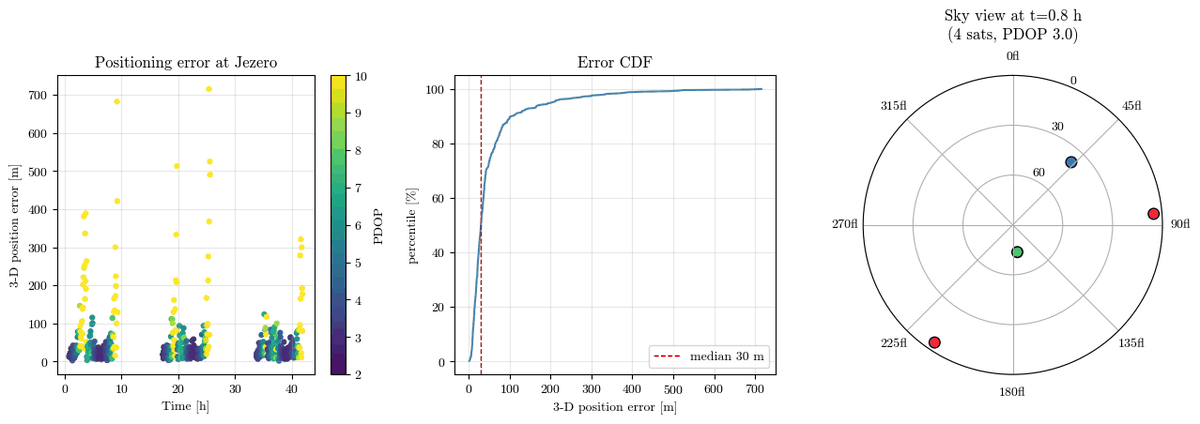

In [13]:
fig = plt.figure(figsize=(13, 4.4))

ax = fig.add_subplot(1, 3, 1)
sc = ax.scatter(epochs_fix, err3d, c=pdop_fix, cmap="viridis", s=12, vmin=2, vmax=10)
ax.set_xlabel("Time [h]"); ax.set_ylabel("3-D position error [m]")
ax.set_title("Positioning error at Jezero"); ax.grid(alpha=0.3)
plt.colorbar(sc, ax=ax, label="PDOP")

ax = fig.add_subplot(1, 3, 2)
xs = np.sort(err3d); ys = np.arange(1, len(xs) + 1) / len(xs)
ax.plot(xs, ys * 100, color="steelblue")
ax.axvline(np.median(err3d), color="red", ls="--", lw=1, label=f"median {np.median(err3d):.0f} m")
ax.set_xlabel("3-D position error [m]"); ax.set_ylabel("percentile [%]")
ax.set_title("Error CDF"); ax.grid(alpha=0.3); ax.legend()

ax = fig.add_subplot(1, 3, 3, projection="polar")
best = np.argmin(pdop_fix)
tt = np.where(np.isclose((TS - EPOCH) / 3600.0, epochs_fix[best]))[0][0]
m = vis_u[:, tt]
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
ax.scatter(az_u[m, tt], 90 - np.rad2deg(elev_u[m, tt]),
           c=[colors[k // SATS_PER_PLANE] for k in np.where(m)[0]], s=70, edgecolors="k")
ax.set_rmax(90); ax.set_rticks([30, 60, 90]); ax.set_yticklabels(["60", "30", "0"])
ax.set_title(f"Sky view at t={epochs_fix[best]:.1f} h\n({m.sum()} sats, PDOP {pdop_fix[best]:.1f})",
             va="bottom")

plt.tight_layout()
plt.show()

## Summary

Using LuPNT's native machinery end to end, we built a simple Mars-PNT study:

* an $8\times8$ **Mars-50c** gravity force model via `Body.Mars` + `NBodyDynamics`, whose
  $J_2\approx2\times10^{-3}$ drives the constellation geometry (the higher-order terms shown directly by
  `compute_accelerations`);
* Mars' native inertial and body-fixed frames (`MARS_CI` / `MARS_FIXED`) via `convert_frame`, with a
  Mars-equatorial design frame derived from LuPNT's own Mars pole;
* a **9/3/1 Walker constellation** at 15,000&nbsp;km, propagated for two sols with `NBodyDynamics` and
  visualized with LuPNT's Plotly body/orbit routines;
* a **median-PDOP surface map** showing where nine satellites already give a usable fix and where the
  minimal fleet leaves gaps; and
* a **pseudorange least-squares positioning** simulation at Jezero Crater, reaching tens-of-metres
  accuracy whenever four or more satellites clear the horizon.
